In [41]:
import subprocess
import pydot
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from collections import defaultdict
from scipy.stats import poisson, norm, chisquare, chi2, binom
import time
import pandas as pd
import numpy as np
import math

In [ ]:
# Чтение файла логов в датафрейм
df = pd.read_csv('../logs/log_sp0.txt', sep='\s+', header=None, names=['p', 'Density', 'Kruslal', 'Prim'])
df["Prim"] = df["Prim"]/(1_000_000)*100
df["Kruslal"] = df["Kruslal"]/(1_000_000)*100*(10)
#df

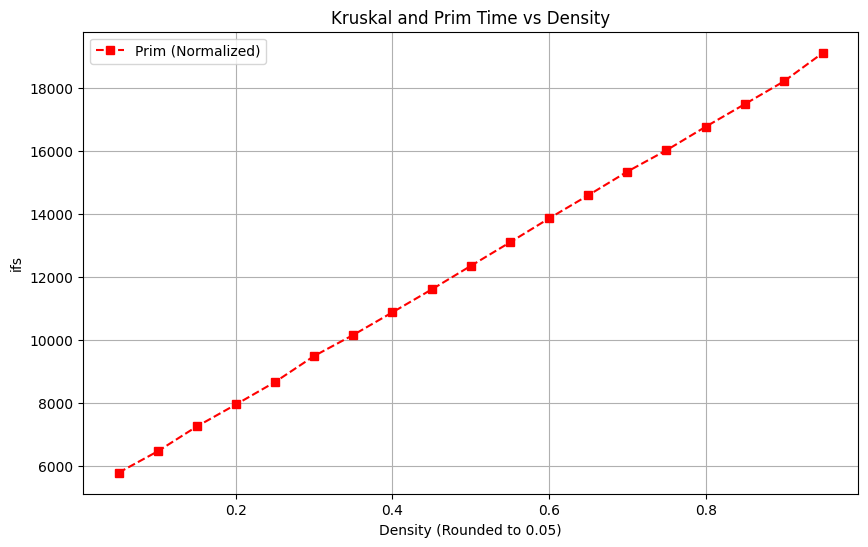

In [ ]:
# Чтение файла логов в датафрейм
df = pd.read_csv('../logs/log_sp0.txt', sep='\s+', header=None, names=['p', 'Density', 'Kruslal', 'Prim'])
df["Prim"] = df["Prim"]
df["Kruslal"] = df["Kruslal"]
#df

# Округление Density до ближайшего 0.05
df['Density_rounded'] = np.round(df['Density'] / 0.05) * 0.05

# Группировка по округлённой Density и усреднение
df_avg = df.groupby('Density_rounded').mean().reset_index()

# Построение графиков
plt.figure(figsize=(10, 6))

# График Kruskal vs Density
plt.plot(df_avg['Density_rounded'], df_avg['Kruslal'], 
         label='Kruskal (Normalized)', marker='o', linestyle='-', color='blue')

# График Prim vs Density
plt.plot(df_avg['Density_rounded'], df_avg['Prim'], 
         label='Prim (Normalized)', marker='s', linestyle='--', color='red')

# Настройки графика
plt.xlabel('Density (Rounded to 0.05)')
plt.ylabel('ifs')
plt.title('Kruskal and Prim Time vs Density')
plt.legend()
plt.grid(True)
plt.show()